# Chengwatana ca. 1096 Ma paleomagnetic pole

## Geologic context

The Chengwatana Volcanics are Keweenawan-age (ca. 1096 Ma) subaerial plateau
basalts of the Midcontinent Rift, exposed as low ridges near St. Croix Falls in
Polk County, Wisconsin (Kean, Williams & Feeney, 1997). Six sites were sampled in
a sequence that dips gently (~10–15°) to the southwest. The characteristic
remanence is carried by magnetite (with minor hematite in the older flows). Most
flows carry a normal-polarity, northwest-and-down direction; two flows near the
top of the sequence (sites 1 and 2) carry a reversed direction, recording a short
reversal within the otherwise-normal Keweenawan sequence. A U-Pb 207Pb/206Pb age
of 1094.6 ± 2.1 Ma on an aphyric rhyolite of the Chengwatana Volcanics (Zartman
et al., 1997) dates the unit.

## Pole

This notebook recreates the Chengwatana pole at the site level from the eight
site-mean directions of Kean et al. (1997) Table 1 (sites 1 and 2 each
contribute a normal and a reversed direction; sites 3–6 are normal). The
combined-polarity Fisher mean of the site VGPs reproduces the published pole
(30.9°N/186.1°E, A95 8.0°). Directions are in situ (the regional dip correction
changes the pole by < 1°).

## Age Constraints

- Current bracket: nominal age 1096 Ma, lomagage 1092 Ma, himagage 1098 Ma.

- A U-Pb 207Pb/206Pb age of 1094.6 ± 2.1 Ma on an aphyric rhyolite of the Chengwatana Volcanics (Zartmanet al., 1997) dates the unit.


## References
- Paleomagnetic source: Kean, W. F., Williams, I., Chan, L., & Feeney, J. (1997). Kean, W. F., Williams, I., Chan, L., & Feeney, J. (1997). Magnetism of the Keweenawan age Chengwatana lava flows, northwest Wisconsin. Geophysical Research Letters, 24(12), 1523–1526. https://doi.org/10.1029/97gl00993

- Geochronology / age-constraint note (compilation): Zartman, R. E., Nicholson, S. W., Cannon, W. F., & Morey, G. B. (1997). U – Th – Pb zircon ages of some Keweenawan Supergroup rocks from the south shore of Lake Superior. Canadian Journal of Earth Sciences, 34(4), 549–561. https://doi.org/10.1139/e17-044


In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

The site means are loaded from the MagIC contribution
`../data/1096_Chengwatana/sites.txt` (transcribed from Kean et al., 1997,
Table 1). All eight site directions are in situ (`dir_tilt_correction = 0`).

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1096_Chengwatana/sites.txt')
sites_pole = sites_geo[sites_geo['dir_comp_name'] == 'ChRM'].reset_index(drop=True)
study_lat, study_lon = 45.37, 267.35
print(f'{len(sites_pole)} site directions ('
      f"{(sites_pole['dir_polarity'] == 'n').sum()} normal, "
      f"{(sites_pole['dir_polarity'] == 'r').sum()} reversed); "
      f"{int(sites_pole['dir_n_samples'].sum())} specimens")
sites_pole[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'dir_polarity', 'vgp_lat', 'vgp_lon']]

8 site directions (6 normal, 2 reversed); 60 specimens


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,dir_polarity,vgp_lat,vgp_lon
0,SC1n,288.9,55.0,49.5,6.9,10,n,36.8,193.4
1,SC1r,114.8,-51.8,5.2,29.2,7,r,-39.1,6.6
2,SC2n,274.0,51.1,13.0,17.0,7,n,24.6,198.5
3,SC2r,106.7,-41.5,6.7,23.1,8,r,-28.2,3.7
4,SC3,280.0,33.2,14.0,20.8,5,n,19.7,183.5
5,SC4,285.1,31.0,16.3,14.1,8,n,22.3,178.9
6,SC5,306.0,45.5,11.2,18.8,7,n,43.7,173.1
7,SC6,287.9,42.6,25.4,11.2,8,n,29.6,183.6


## Site location map

In [3]:
pt.plot_site_map(sites_pole, zoom_start=11)

## Mean pole from VGPs

The pole is the Fisher mean of the eight site VGPs with polarity unified.

Plon: 185.3  Plat: 30.7
Number of directions in mean (n): 8
Angular radius of 95% confidence (A_95): 7.5
Precision parameter (k) estimate: 55.7

Kean et al. (1997), average N and R: 30.9 N / 186.1 E, A95 8.0, N=8


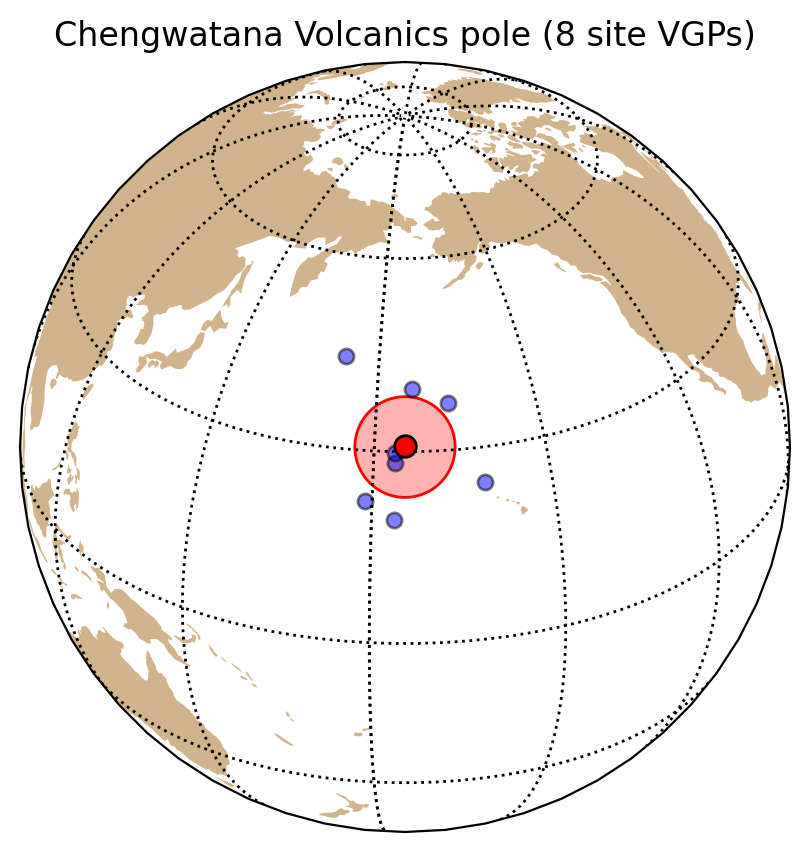

In [4]:
vgp_block, pole_mean = pt.compute_mean_pole(sites_pole, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nKean et al. (1997), average N and R: 30.9 N / 186.1 E, A95 8.0, N=8')
pole_plot = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                                  central_latitude=pole_mean['inc'], figsize=(5, 5))
plt.title('Chengwatana Volcanics pole (8 site VGPs)')
plt.show()

## Site directions (as measured at site)

In [5]:
dir_block, dir_mean = pt.compute_mean_direction(sites_pole, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)

Dec: 287.7  Inc: 44.3
Number of directions in mean (n): 8
Angular radius of 95% confidence (a_95): 7.6
Precision parameter (k) estimate: 54.6


## Reversal test

Sites 1 and 2 carry reversed directions that are approximately antipodal to the
dominant normal direction of the swarm. The McFadden & McElhinny (1990) and
bootstrap reversal tests are applied to the eight site directions (split by the
principal eigenvector, no prior polarity unification). With only two reversed
sites — which the paper notes have large within-site scatter (α95 23–29°) — the
test is of low resolution.

8 directions (polarity 1: 6, polarity 2: 2)

McFadden & McElhinny (1990) reversal test
------------------------------------------


Results of Watson V test: 

Watson's V:           0.6
Critical value of V:  8.9
"Pass": Since V is less than Vcrit, the null hypothesis
that the two populations are drawn from distributions
that share a common mean direction can not be rejected.

M&M1990 classification:

Angle between data set means: 4.1
Critical angle for M&M1990:   16.3
The McFadden and McElhinny (1990) classification for
this test is: 'C'


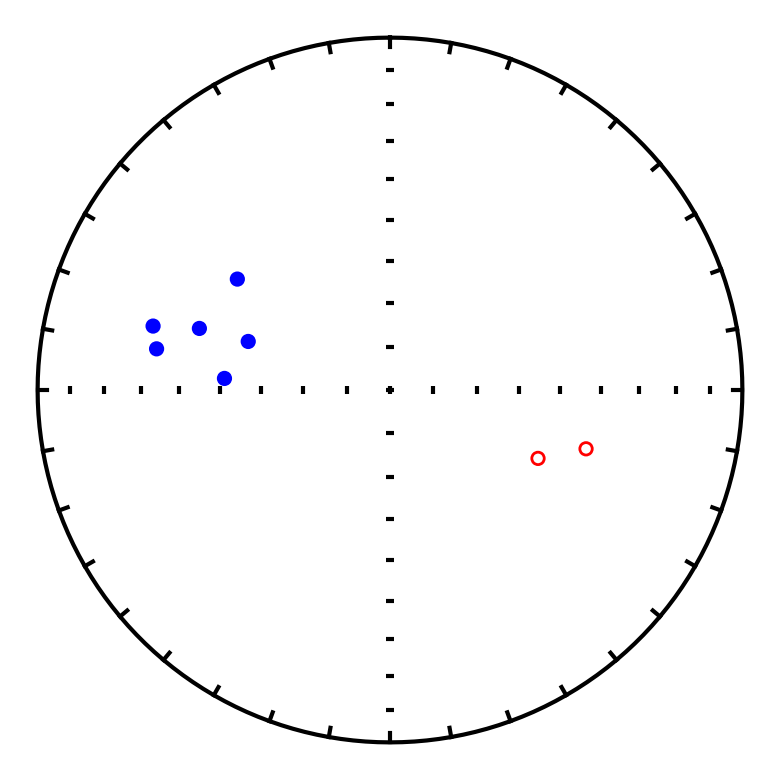


Bootstrap reversal test
------------------------------------------


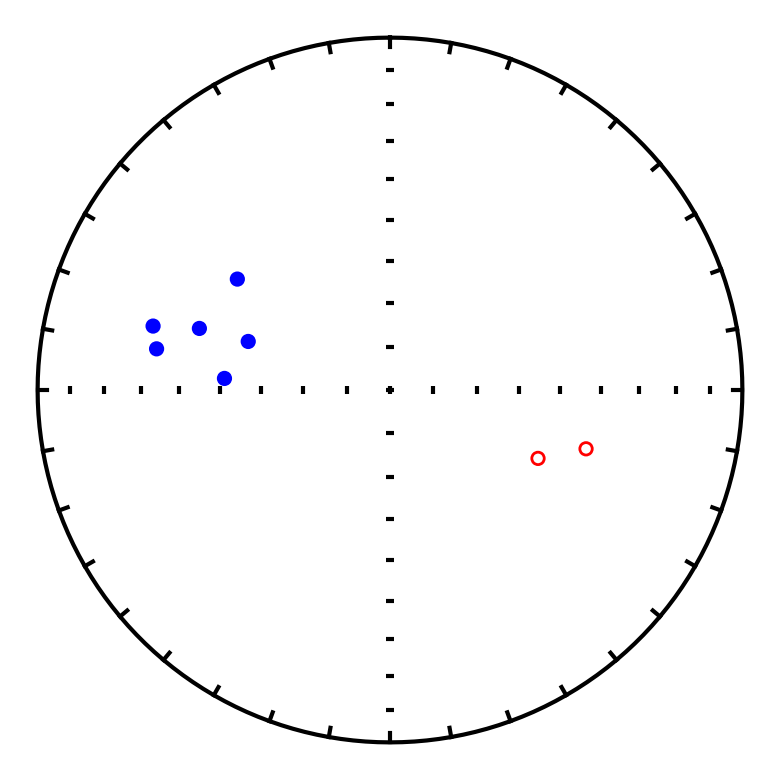

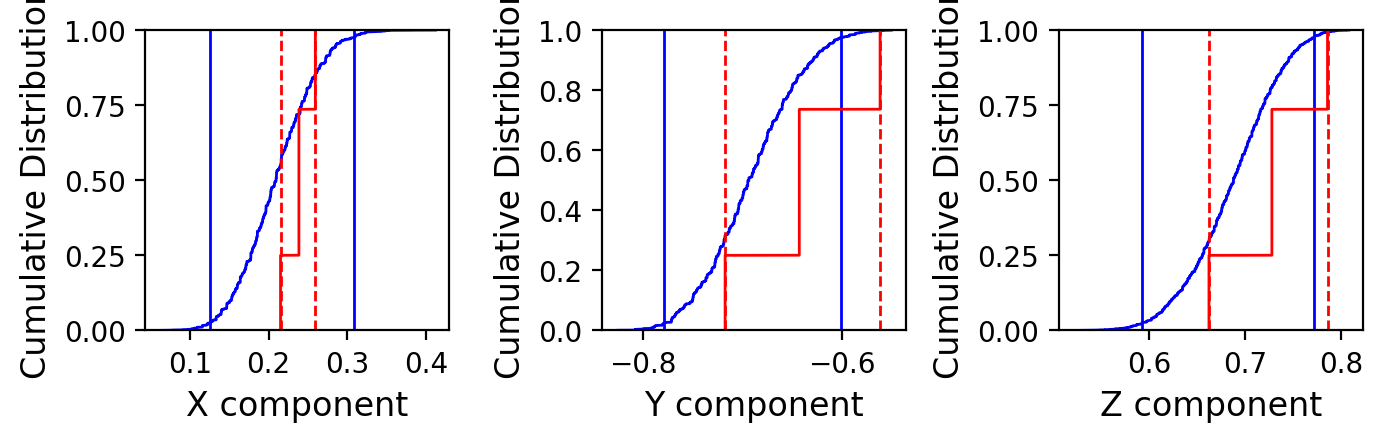

Pass


In [6]:
_ = pt.reversal_test(sites_pole, plot=True, random_seed=1)

## The Chengwatana pole in the context of the Laurentia APWP

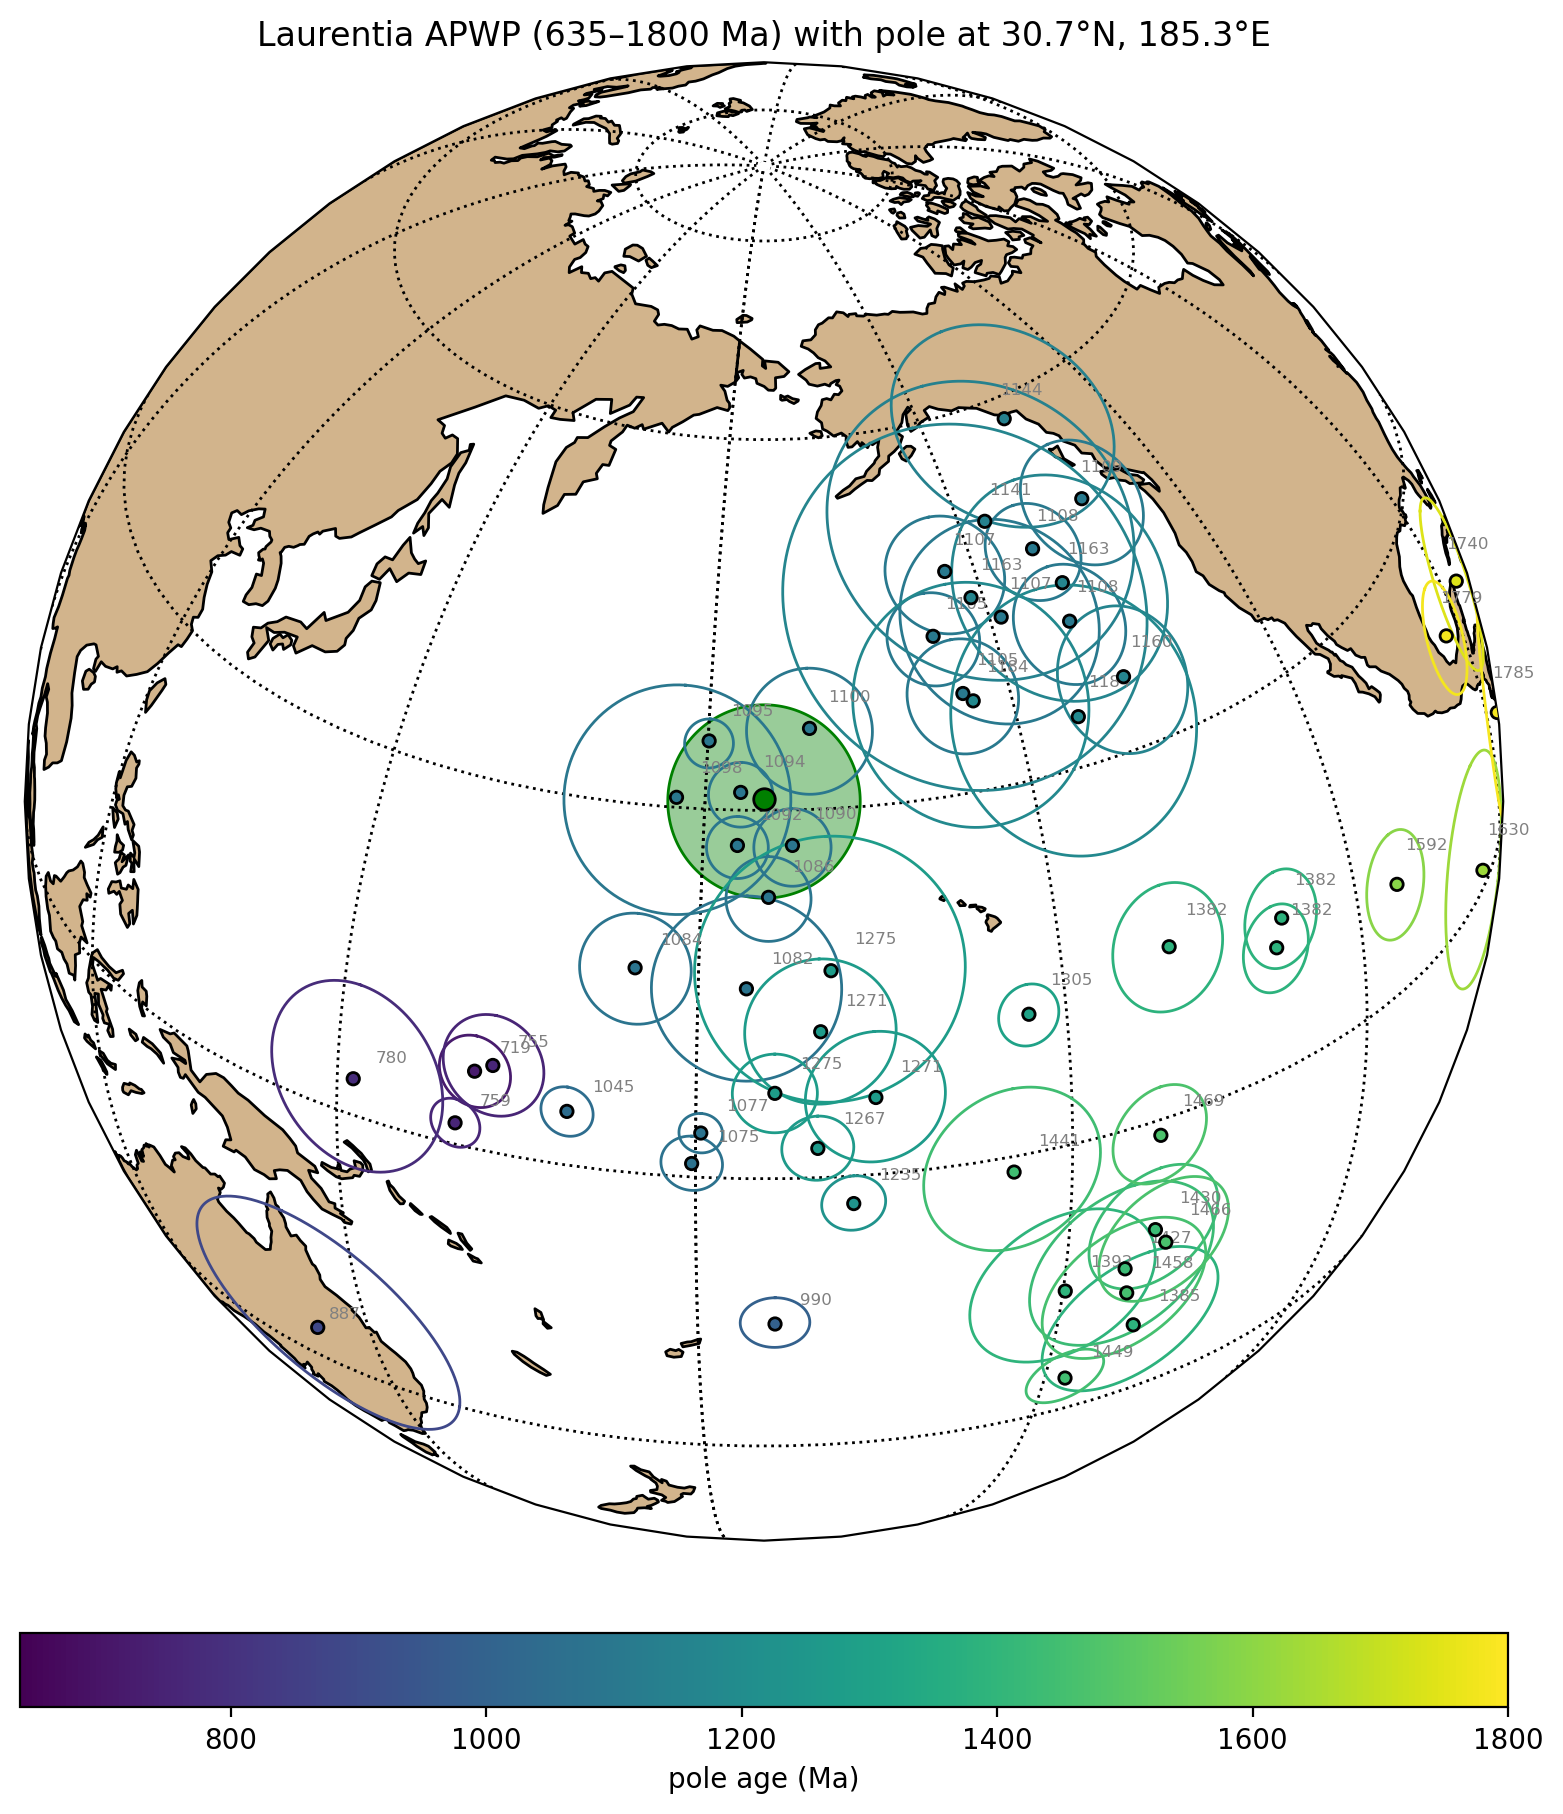

In [7]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R2: Techniques and statistical analysis (Meert et al., 2020)

A_95 of 7.5 passes Deenen et al. (2011) criteria of being between 5.2 and 22.1 for this number of sites


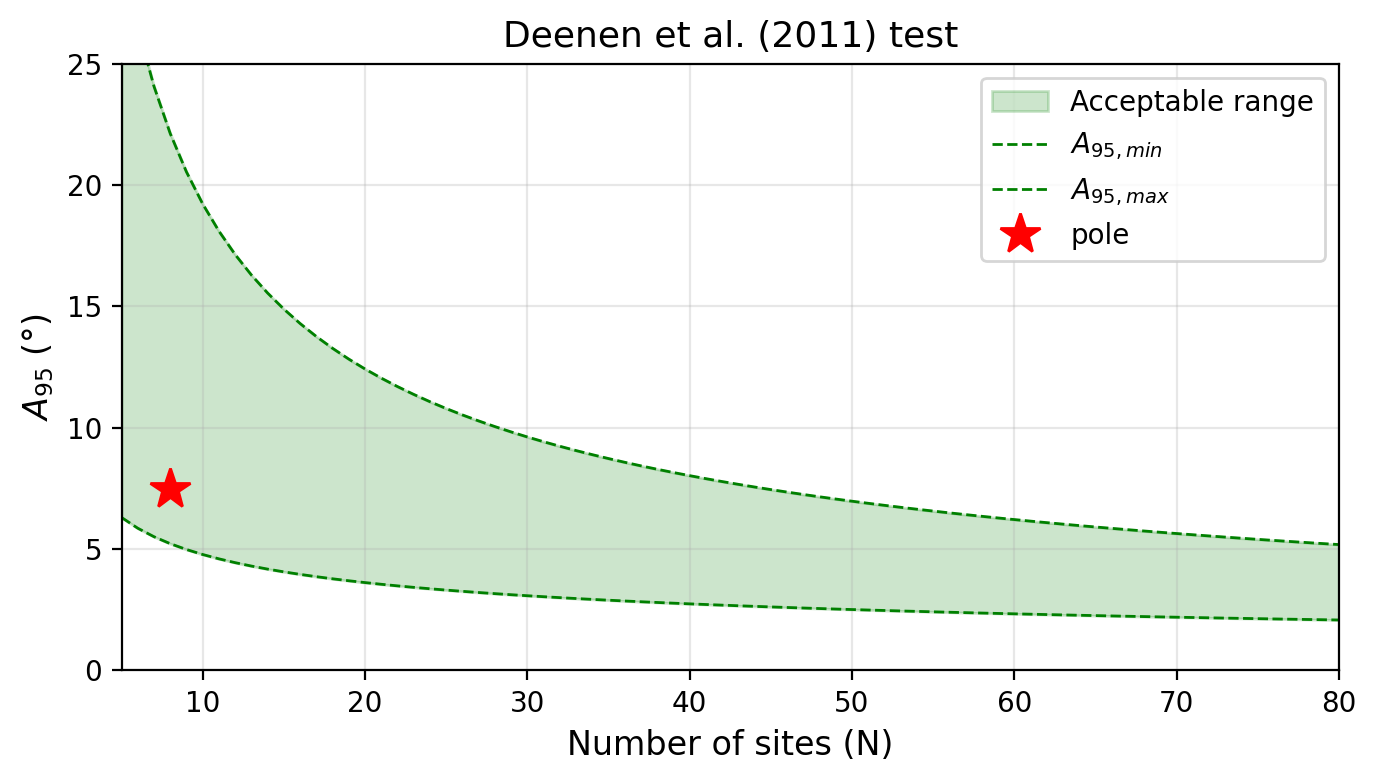

In [8]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()

### Paleosecular variation — Fisher Q–Q and SVEI

The Fisher quantile–quantile (fishqq) test evaluates whether the site VGPs are
Fisher-distributed, and the shape-elongation/inclination (SVEI) test compares the
VGP elongation and V2 declination against the TK03.GAD paleosecular-variation
model.

In [9]:
fishqq_result = pt.fishqq_vgps(sites_pole, unify_polarity=True)
fishqq_result

you need N> 10 for at least one mode


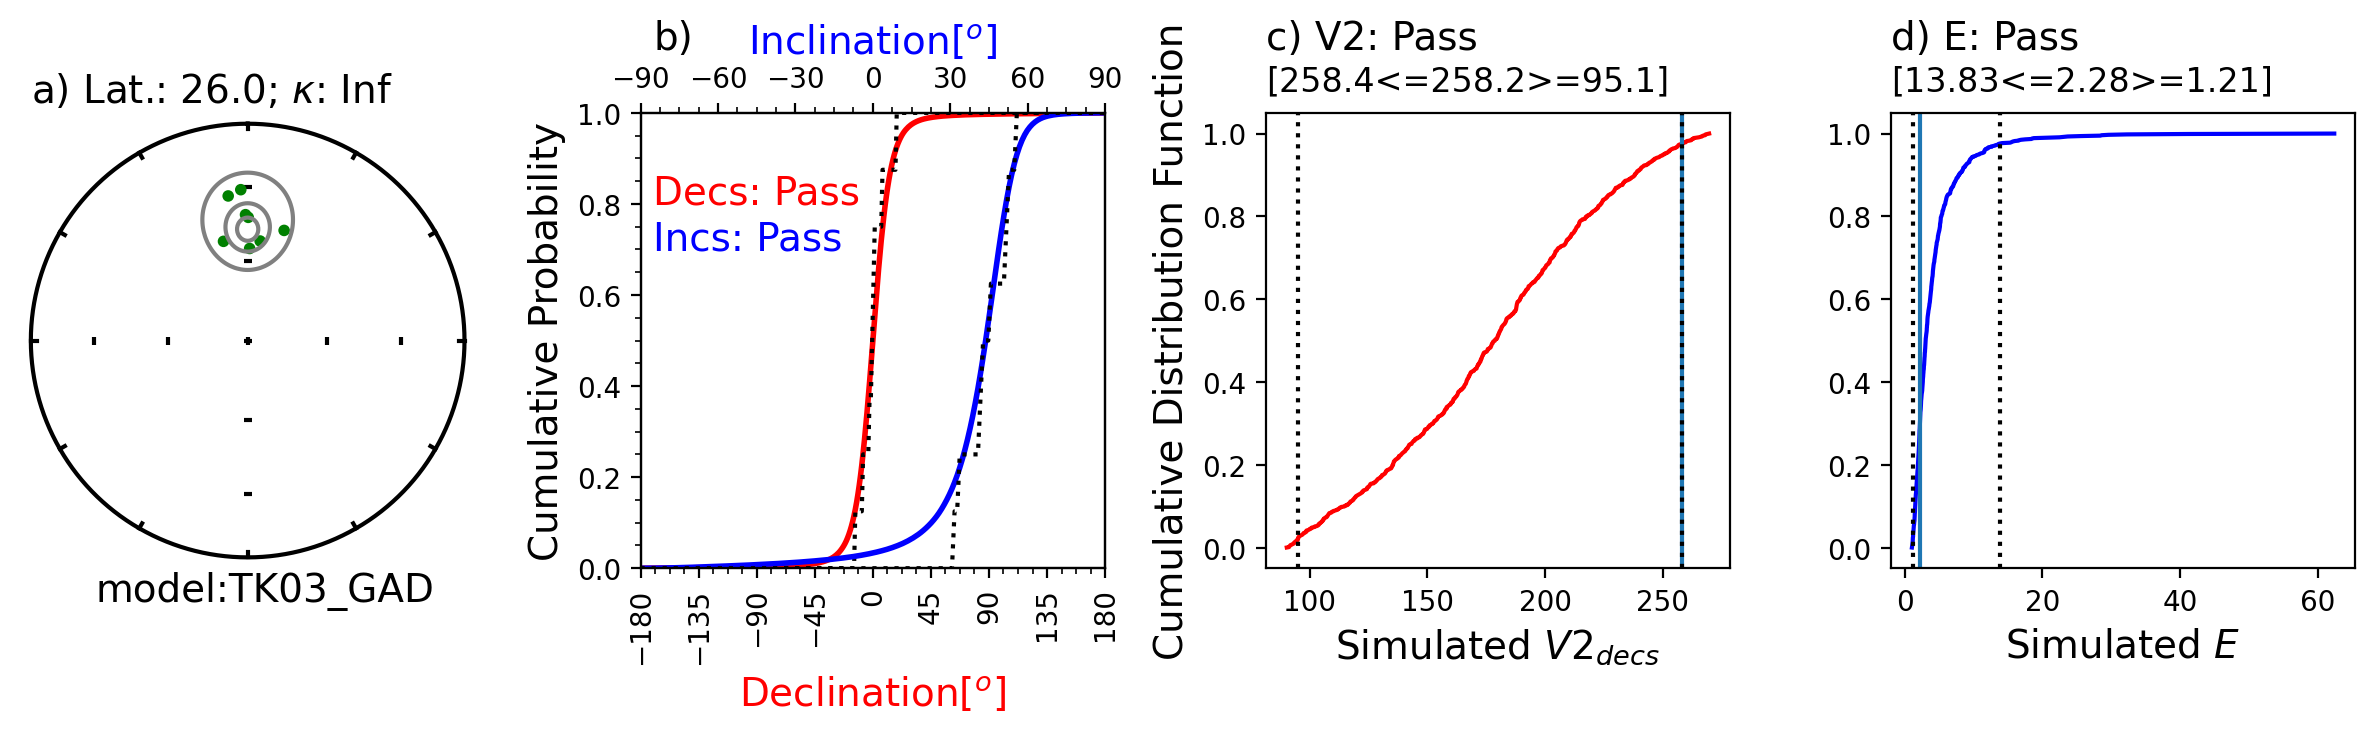

paleolatitude = 26.0 deg; elongation E = 2.28 (consistent with TK03.GAD)


In [10]:
try:
    svei_result = pt.svei_test_vgps(sites_pole, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sites_pole, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## R7: comparison with younger Laurentia poles

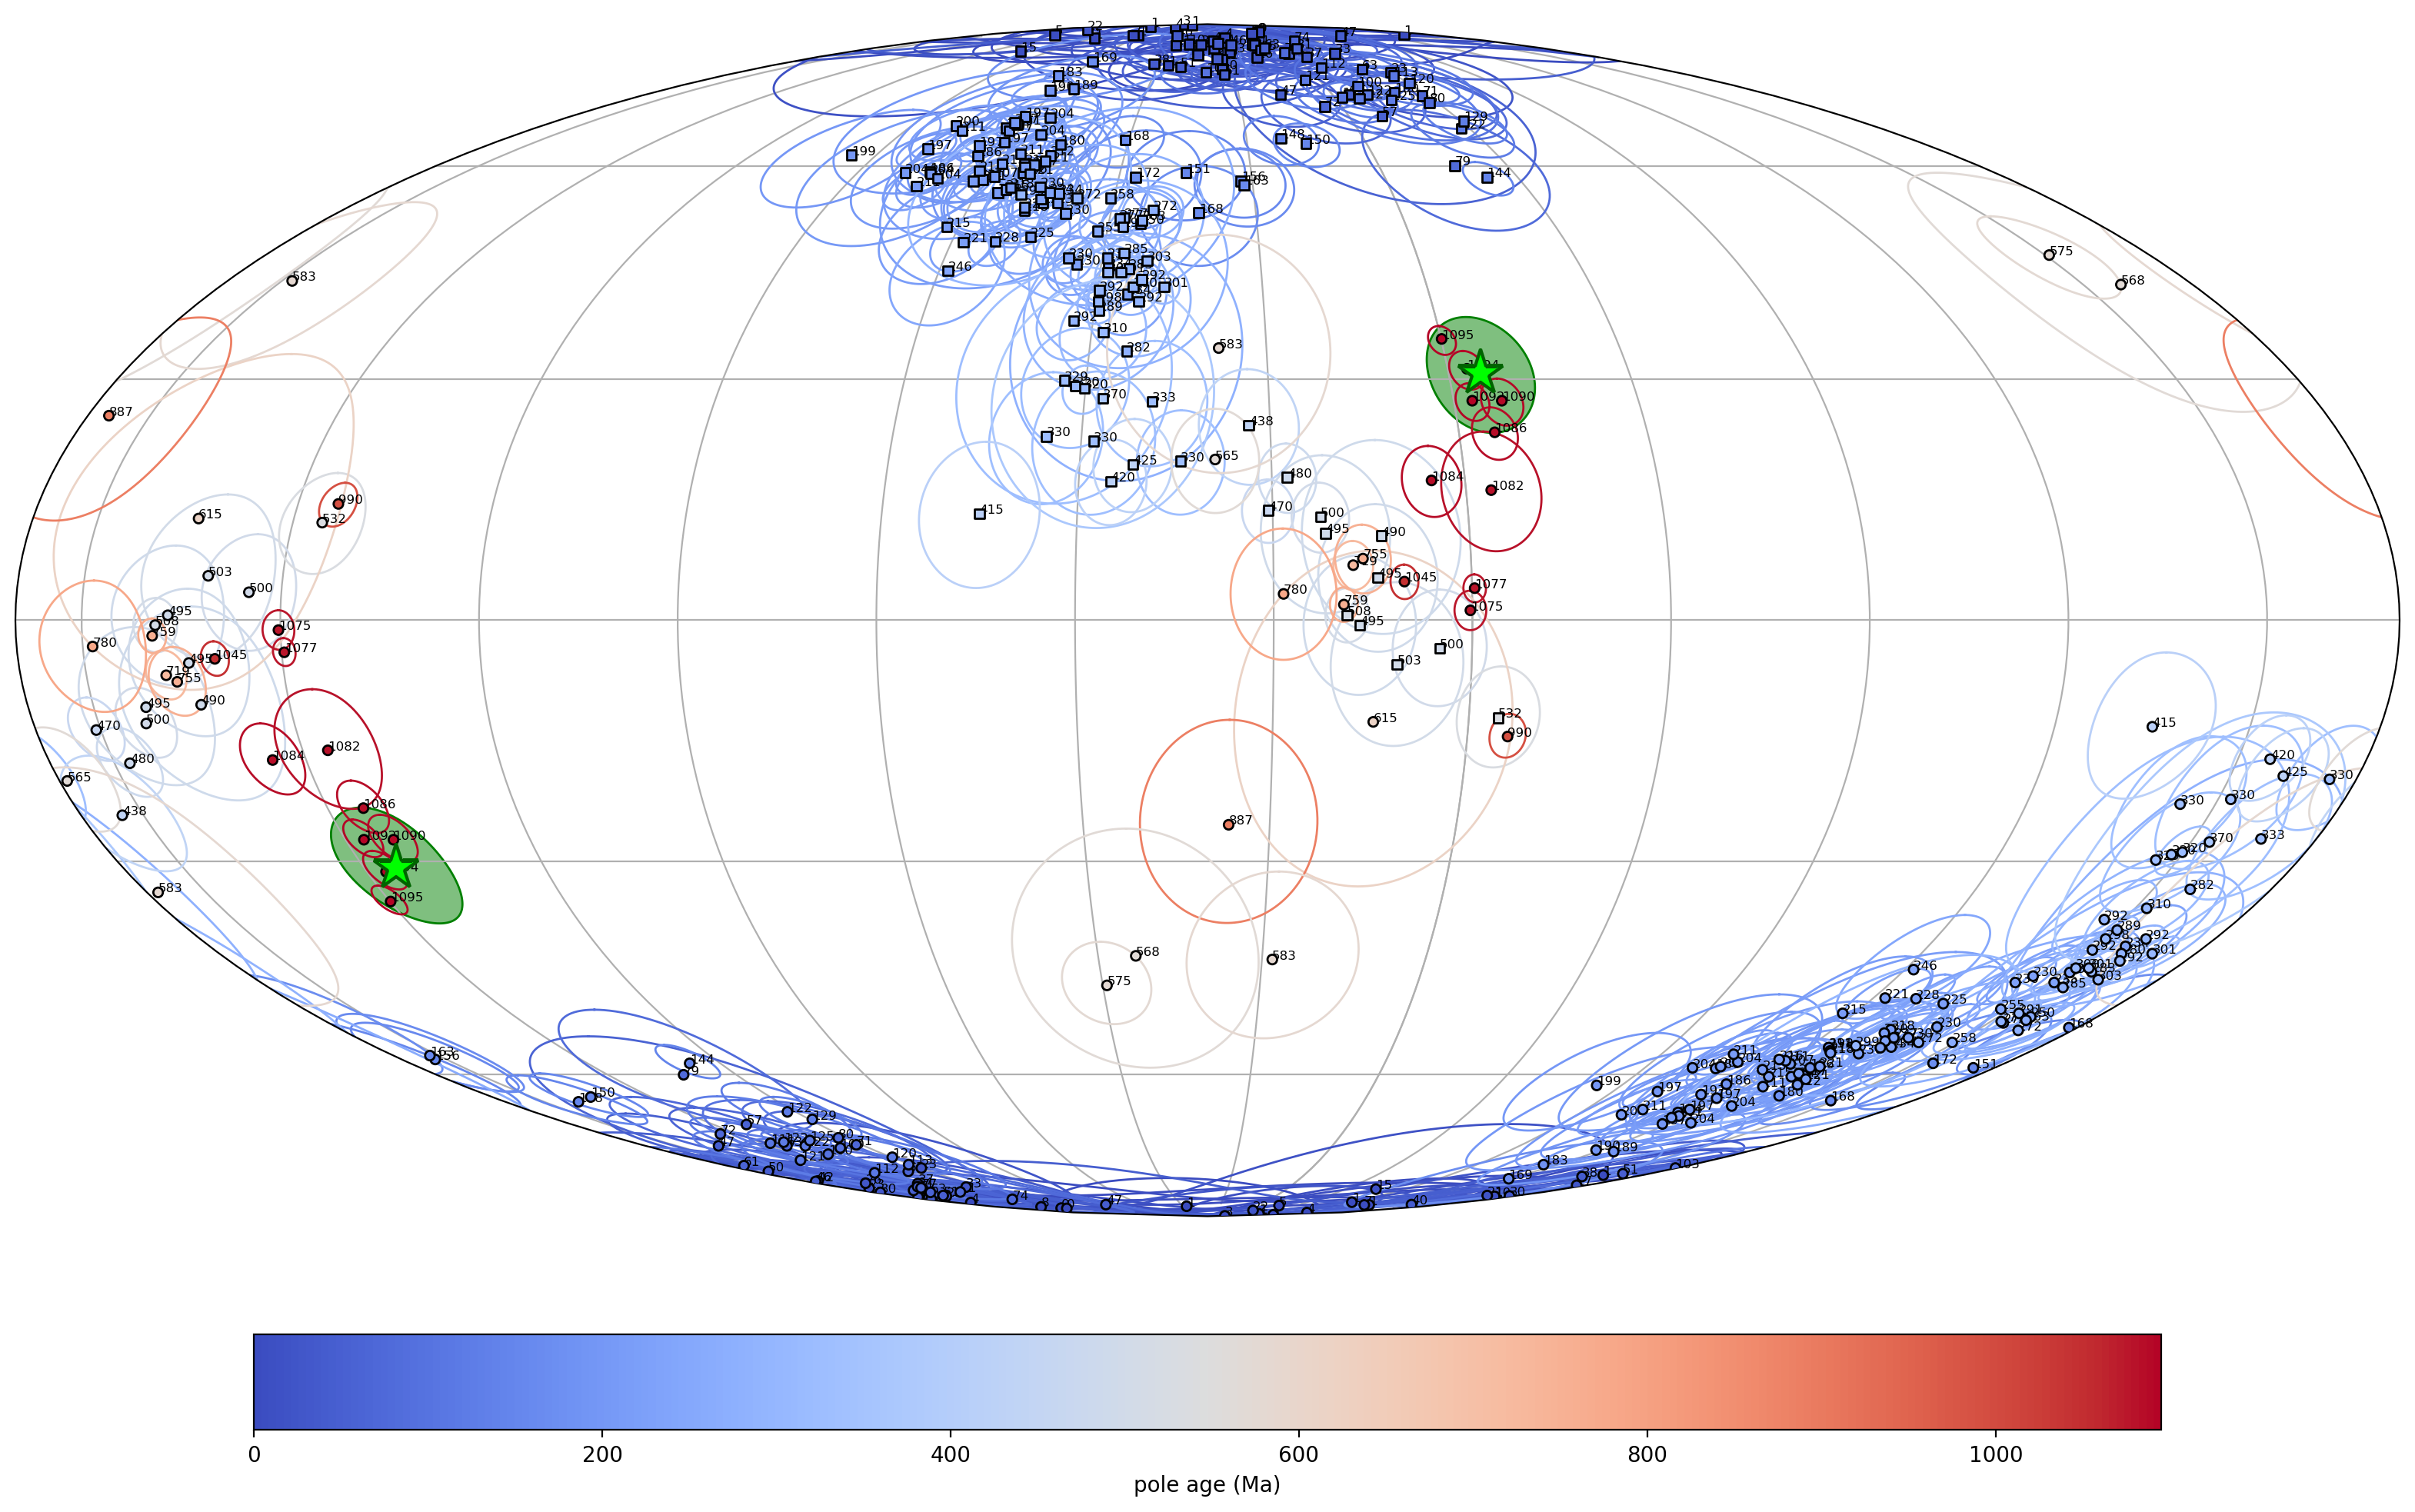

In [11]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
_ = pt.plot_pole_overlap('Chengwatana Volcanics', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1095)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb 207Pb/206Pb 1094.6 ± 2.1 Ma on an aphyric rhyolite of the Chengwatana Volcanics (Zartman et al., 1997). |
| 2 | Techniques and statistical analysis | **1** | AF + thermal demagnetization with PCA; N = 8 site directions (60 specimens), A95 = 7.5°. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by magnetite (minor hematite), characterized by IRM/demagnetization (Kean et al., 1997). |
| 4 | Field tests constrain age of magnetization | **0** | No baked-contact or fold test constraining the age of magnetization. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Midcontinent Rift; the regional dip correction shifts the pole < 1°. |
| 6 | Presence of reversals | **1** | Dual polarity — sites 1 and 2 record a reversed interval within the normal sequence. |
| 7 | No resemblance to younger poles | **1** | A Keweenawan-track pole, distinct from younger Laurentia poles. |
| | Total | **6/7** | Grade B |

## Comparison with the published pole

### ChRM pole

| Quantity | This study (site VGPs) | Kean et al. (1997) | Previous Nordic compilation |
|---|---|---|---|
| Component | ChRM (combined N + R) | average N and R | — |
| N (sites) | 8 | 8 | 8 |
| N (specimens) | 60 | 60 | 60 |
| Dec (°) | 287.7 | 287.5 | 287.5 |
| Inc (°) | 44.3 | 45.8 | 45.8 |
| k (direction) | 54.6 | 48.5 | 48.5 |
| α95 (direction, °) | 7.6 | 8.0 | 8.0 |
| Pole lat (°N) | 30.7 | 30.9 | 30.9 |
| Pole lon (°E) | 185.3 | 186.1 | 186.1 |
| A95 (°) | 7.5 | — | 8.2 |
| dp / dm (°) | — | — | 6.5 / 10.3 |

"This study" is the Fisher mean of the eight site VGPs recomputed here; Kean et al.
(1997) is their Table 1 "average N and R" row; the compilation is the Evans et al.
(2021) Chengwatana Volcanics entry (GPMDB 8163).

In [12]:
chengwatana_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Chengwatana Volcanics',
    sites=sites_pole,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (magnetite; minor hematite); dual polarity (sites 1-2 record a short reversal)',
    tests='R (reversal/dual polarity; sites 1 and 2 reversed)',
    gpmdb_number='8163',
    percent_reversed=25,
    demag_code=4,
    R1=1, R2=0, R3=1, R4='', R5=1, R6=1, R7=1, Grade='C', Grade_E21='B',
    nominal_age=1096, lomagage=1092, himagage=1098,
    REF_method="- Current bracket: nominal age 1096 Ma, lomagage 1092 Ma, himagage 1098 Ma.\n\n- A U-Pb 207Pb/206Pb age of 1094.6 ± 2.1 Ma on an aphyric rhyolite of the Chengwatana Volcanics (Zartmanet al., 1997) dates the unit.",
    POLE_AUTHORS='Kean, W. F., Williams, I., & Feeney, J.',
    YEAR=1997,
    JOURNAL='Geophysical Research Letters',
    VOLUME='24',
    VPAGES='1523-1526',
    TITLE='Magnetism of the Keweenawan age Chengwatana lava flows, northwest Wisconsin',
    COMMENT='Pole calculated from 8 site-mean VGPs as documented in Swanson-Hysell et al. 2026; note that the definition of a site in Kean et al., may not correspond to an individual cooling unit which may help explain the low within site precision. Graded C and excluded from the compilation: without site definitions that correspond to individual cooling units, R2(c) is not met and there is no basis on which to judge whether paleosecular variation is averaged.'
)
pt.save_nordic_summary(chengwatana_summary, '1096_Chengwatana')
chengwatana_summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia,Chengwatana Volcanics,8163,,Characteristic remanent magnetization (magneti...,R (reversal/dual polarity; sites 1 and 2 rever...,0,45.37,267.35,8,...,"- Current bracket: nominal age 1096 Ma, lomaga...",Chengwatana Volcanics,"Kean, W. F., Williams, I., & Feeney, J.",1997,Geophysical Research Letters,24,1523-1526,Magnetism of the Keweenawan age Chengwatana la...,Pole calculated from 8 site-mean VGPs as docum...,Basalt
